In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Galaxy10_DECals.h5"

print("\nDataset exists:", os.path.exists(DATA_PATH))

if os.path.exists(DATA_PATH):
    size_gb = os.path.getsize(DATA_PATH) / (1024**3)
    print(f"Dataset size: {size_gb:.2f} GB")

Mounted at /content/drive

Dataset exists: True
Dataset size: 2.55 GB


Connected Google Drive to the Colab environment and specified the path to the Galaxy10 DECals dataset and verified that the dataset exists and reported its storage size.

In [ ]:
import h5py
import numpy as np

with h5py.File(DATA_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    print("Images shape:", f["images"].shape)
    print("Images dtype:", f["images"].dtype)
    print("Labels shape:", f["ans"].shape)
    print("Unique labels:", np.unique(f["ans"]))

    print("\nClass counts:")
    print(np.bincount(f["ans"][:]))

Keys: ['ans', 'dec', 'images', 'pxscale', 'ra', 'redshift']
Images shape: (17736, 256, 256, 3)
Images dtype: uint8
Labels shape: (17736,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]

Class counts:
[1081 1853 2645 2027  334 2043 1829 2628 1423 1873]


Imported the required libraries for dataset handling, numerical computation, visualization, model development, and evaluation.

Inspected the HDF5 dataset structure by checking its available keys, image dimensions, data type, label dimensions, unique classes, and the number of samples in each class.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

with h5py.File(DATA_PATH, "r") as f:
    labels = f["ans"][:]

indices = np.arange(len(labels))

# 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Split the remaining 30% equally into validation and test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels[temp_idx],
    random_state=42
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 12415
Validation: 2660
Test: 2661


Created training, validation, and testing subsets using stratified sampling so that the class distribution was maintained across the splits. The dataset was divided into 12,415 training images, 2,660 validation images, and 2,661 test images.

In [ ]:
CACHE_PATH = "/content/Galaxy10_DECals_local.h5"

if os.path.exists(CACHE_PATH):
    size_gb = os.path.getsize(CACHE_PATH) / (1024**3)
    print(f"Local cache found: {CACHE_PATH}")
    print(f"Cache size: {size_gb:.2f} GB")
else:
    print("Local cache NOT found.")

Local cache NOT found.


Checked whether a local copy of the dataset was already available in the Colab environment and displayed its size if found.

In [ ]:
import shutil

total, used, free = shutil.disk_usage("/content")

print(f"Total space: {total / (1024**3):.2f} GB")
print(f"Used space:  {used / (1024**3):.2f} GB")
print(f"Free space:  {free / (1024**3):.2f} GB")

Total space: 112.64 GB
Used space:  47.49 GB
Free space:  65.13 GB


Checked the total, used, and available disk space in the Colab environment to ensure there was enough storage for creating local dataset caches.

In [ ]:
import h5py
import shutil
import os

CACHE_PATH = "/content/Galaxy10_DECals_local.h5"

with h5py.File(DATA_PATH, "r") as src, h5py.File(CACHE_PATH, "w") as dst:
    src.copy("images", dst)
    src.copy("ans", dst)

print("Local cache created successfully.")
print(f"Path: {CACHE_PATH}")
print(f"Size: {os.path.getsize(CACHE_PATH) / (1024**3):.2f} GB")

Local cache created successfully.
Path: /content/Galaxy10_DECals_local.h5
Size: 2.55 GB


Created a local HDF5 cache containing the image and label datasets so that the data could be accessed locally during model development.

In [ ]:
def load_images_from_hdf5(indices):
    indices = np.asarray(indices, dtype=np.int64)

    sort_order = np.argsort(indices)
    sorted_indices = indices[sort_order]

    with h5py.File(CACHE_PATH, "r") as f:
        images_sorted = f["images"][sorted_indices]

    restore_order = np.argsort(sort_order)
    images = images_sorted[restore_order]

    images = images.astype(np.float32) / 255.0

    return images

Developed a function to load selected images from the HDF5 cache. The indices were sorted for efficient access, the original order was restored afterward, and the image pixel values were normalized from 0–255 to 0–1.

In [ ]:
import time

test_indices = train_idx[:32]

start = time.time()
test_images = load_images_from_hdf5(test_indices)
elapsed = time.time() - start

print("Batch shape:", test_images.shape)
print("Dtype:", test_images.dtype)
print("Min value:", test_images.min())
print("Max value:", test_images.max())
print(f"Loading time: {elapsed:.2f} seconds")

Batch shape: (32, 256, 256, 3)
Dtype: float32
Min value: 0.0
Max value: 1.0
Loading time: 21.47 seconds


Loaded a sample batch of 32 images to verify the loader's output shape, data type, normalized pixel range, and loading time.

In [ ]:
with h5py.File(CACHE_PATH, "r") as f:
    images_shape = f["images"].shape
    images_dtype = f["images"].dtype

print("Images shape:", images_shape)
print("Images dtype:", images_dtype)

required_gb = (
    np.prod(images_shape) * np.dtype(np.float32).itemsize
) / (1024**3)

print(f"Float32 cache would require: {required_gb:.2f} GB")

Images shape: (17736, 256, 256, 3)
Images dtype: uint8
Float32 cache would require: 12.99 GB


Checked the original image dimensions and calculated how much storage would be required if the complete image dataset were converted to Float32 format.

In [ ]:
import numpy as np
import h5py
import os

NPY_PATH = "/content/Galaxy10_images.npy"

with h5py.File(CACHE_PATH, "r") as f:
    images = f["images"][:]

np.save(NPY_PATH, images)

del images

size_gb = os.path.getsize(NPY_PATH) / (1024**3)

print("NumPy cache created successfully.")
print(f"Path: {NPY_PATH}")
print(f"Size: {size_gb:.2f} GB")

NumPy cache created successfully.
Path: /content/Galaxy10_images.npy
Size: 3.25 GB


Converted the images from the HDF5 cache into a NumPy .npy file. This created a local NumPy-based representation of the image dataset for faster access.

In [ ]:
images_memmap = np.load(NPY_PATH, mmap_mode="r")

print("Shape:", images_memmap.shape)
print("Dtype:", images_memmap.dtype)
print("Memory-mapped:", isinstance(images_memmap, np.memmap))

Shape: (17736, 256, 256, 3)
Dtype: uint8
Memory-mapped: True


Loaded the NumPy image file using memory mapping so that the complete dataset did not have to be loaded into RAM at once.

In [ ]:
import time

test_indices = train_idx[:32]

start = time.time()

test_images = images_memmap[test_indices].astype(np.float32) / 255.0

elapsed = time.time() - start

print("Batch shape:", test_images.shape)
print("Dtype:", test_images.dtype)
print("Min value:", test_images.min())
print("Max value:", test_images.max())
print(f"Loading time: {elapsed:.2f} seconds")

Batch shape: (32, 256, 256, 3)
Dtype: float32
Min value: 0.0
Max value: 1.0
Loading time: 0.09 seconds


Tested the memory-mapped approach using a batch of 32 images and compared its loading performance after normalization. The loading time was substantially lower than the earlier HDF5 test.

In [ ]:
def load_images_from_memmap(indices):
    indices = np.asarray(indices, dtype=np.int64)
    images = images_memmap[indices]
    images = images.astype(np.float32) / 255.0
    return images

print("Fast memmap loader ready.")

Fast memmap loader ready.


Defined a reusable memory-mapped image-loading function that retrieves selected images and converts them to normalized Float32 values.

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32

def load_batch(indices, labels):
    images = load_images_from_memmap(indices)
    return images, labels

def tf_load_batch(indices, labels):
    images, labels = tf.numpy_function(
        load_batch,
        [indices, labels],
        [tf.float32, tf.int64]
    )

    images.set_shape([None, 256, 256, 3])
    labels.set_shape([None])

    return images, labels

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_idx, labels[train_idx]))
    .shuffle(len(train_idx), seed=42)
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_idx, labels[val_idx]))
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_idx, labels[test_idx]))
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 388
Validation batches: 84
Test batches: 84


Created TensorFlow training, validation, and testing datasets using tf.data. The pipeline performs batching, training-data shuffling, parallel loading, and prefetching to improve data delivery during model training.

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Checked the installed TensorFlow version and confirmed that a GPU was available for model computation.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

cnn = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,602 (1.61 MB)

 Trainable params: 422,602 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Developed a convolutional neural network for the 10-class galaxy morphology classification task. The architecture uses four convolutional blocks with increasing feature channels, max-pooling for spatial reduction, global average pooling, a dense layer, dropout regularization, and a 10-class softmax output layer.

In [ ]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN compiled successfully.")

CNN compiled successfully.


Configured the CNN for training using the Adam optimizer with a learning rate of 1e-4, sparse categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

In [ ]:
import os

CNN_SAVE_DIR = "/content/drive/MyDrive/Galaxy10_CNN"
os.makedirs(CNN_SAVE_DIR, exist_ok=True)

CNN_CHECKPOINT = os.path.join(
    CNN_SAVE_DIR,
    "best_cnn.weights.h5"
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CNN_CHECKPOINT,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Checkpoint:", CNN_CHECKPOINT)
print("Callbacks ready.")

Checkpoint: /content/drive/MyDrive/Galaxy10_CNN/best_cnn.weights.h5
Callbacks ready.


Created a directory for storing the CNN results and configured training callbacks. The best model weights were saved according to validation accuracy, early stopping was used when validation performance stopped improving, and the learning rate was reduced when validation loss plateaued.

In [ ]:
def load_batch(indices, labels):
    images = load_images_from_memmap(indices)
    labels = np.asarray(labels, dtype=np.int64)
    return images, labels

def tf_load_batch(indices, labels):
    images, labels = tf.numpy_function(
        load_batch,
        [indices, labels],
        [tf.float32, tf.int64]
    )

    images.set_shape([None, 256, 256, 3])
    labels.set_shape([None])

    return images, labels

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_idx, labels[train_idx]))
    .shuffle(len(train_idx), seed=42)
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_idx, labels[val_idx]))
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_idx, labels[test_idx]))
    .batch(BATCH_SIZE)
    .map(tf_load_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pipeline rebuilt successfully.")

Dataset pipeline rebuilt successfully.


Rebuilt the training, validation, and test pipelines using the memory-mapped image loader and explicitly converted labels to the required integer format.

In [ ]:
import time

x_batch, y_batch = next(iter(train_ds))

start = time.time()

with tf.device("/GPU:0"):
    predictions = cnn(x_batch, training=True)

elapsed = time.time() - start

print("Images:", x_batch.shape)
print("Labels:", y_batch.shape)
print("Predictions:", predictions.shape)
print(f"Batch computation time: {elapsed:.2f} seconds")

Images: (32, 256, 256, 3)
Labels: (32,)
Predictions: (32, 10)
Batch computation time: 4.68 seconds


Passed one training batch through the CNN on the GPU to verify the image and label shapes, confirm that the model produced 10-class predictions, and measure the batch computation time.

In [ ]:
class_weights = {
    0: 1.640,
    1: 0.957,
    2: 0.671,
    3: 0.875,
    4: 5.306,
    5: 0.868,
    6: 0.970,
    7: 0.675,
    8: 1.246,
    9: 0.947
}

history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1002 - loss: 2.2978
Epoch 1: val_accuracy improved from None to 0.12895, saving model to /content/drive/MyDrive/Galaxy10_CNN/best_cnn.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Galaxy10_CNN/best_cnn.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 59s 125ms/step - accuracy: 0.1052 - loss: 2.3017 - val_accuracy: 0.1289 - val_loss: 2.2947 - learning_rate: 1.0000e-04
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1335 - loss: 2.2752
Epoch 2: val_accuracy improved from 0.12895 to 0.17406, saving model to /content/drive/MyDrive/Galaxy10_CNN/best_cnn.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Galaxy10_CNN/best_cnn.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.1580 - loss: 2.1983 - val_accuracy: 0.1741 - val_loss: 2.0717 - learning_rate: 1.0000e-04
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1883 - loss: 2.1144
Epoch 3: 

Trained the CNN for up to 30 epochs using class weights to give greater importance to underrepresented classes. Validation data and the configured callbacks were used to monitor and control the training process.

In [ ]:
history_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_history.npy"

np.save(
    history_path,
    history.history,
    allow_pickle=True
)

print("Training history saved.")
print("Path:", history_path)
print("Recorded epochs:", len(history.history["loss"]))

Training history saved.
Path: /content/drive/MyDrive/Galaxy10_CNN/cnn_history.npy
Recorded epochs: 30


Saved the recorded training history, including training and validation loss and accuracy, so that the learning curves could be analyzed later.

In [ ]:
test_loss, test_accuracy = cnn.evaluate(test_ds, verbose=1)

print(f"\nCNN Test Loss: {test_loss:.4f}")
print(f"CNN Test Accuracy: {test_accuracy:.4f}")
print(f"CNN Test Accuracy: {test_accuracy * 100:.2f}%")

84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.4480 - loss: 1.5068

CNN Test Loss: 1.5068
CNN Test Accuracy: 0.4480
CNN Test Accuracy: 44.80%


Evaluated the trained CNN on the unseen test dataset and recorded the final test loss and test accuracy.

In [ ]:
y_true = []
y_pred = []
y_prob = []

for x_batch, y_batch in test_ds:
    predictions = cnn.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(np.max(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (2661,)
Predictions: (2661,)
Probabilities: (2661,)


Ran the trained CNN over the complete test set and collected the true labels, predicted classes, and prediction confidence values for further evaluation.

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.2605    0.4198    0.3215       162
           1     0.3483    0.3345    0.3413       278
           2     0.5172    0.6045    0.5575       397
           3     0.5776    0.3059    0.4000       304
           4     0.2791    0.2400    0.2581        50
           5     0.3333    0.2410    0.2798       307
           6     0.3470    0.6764    0.4587       275
           7     0.5217    0.2132    0.3027       394
           8     0.7566    0.5399    0.6301       213
           9     0.5761    0.8078    0.6726       281

    accuracy                         0.4480      2661
   macro avg     0.4518    0.4383    0.4222      2661
weighted avg     0.4736    0.4480    0.4349      2661



Generated a classification report containing precision, recall, and F1-score for each of the ten galaxy morphology classes, along with macro and weighted averages.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(y_true, y_pred)

print("CNN Confusion Matrix:")
print(cm_cnn)

CNN Confusion Matrix:
[[ 68  14  27  12   3   3  14  11   0  10]
 [ 15  93  52   6   3  14  38   8  17  32]
 [ 17  49 240  30   0  19  26   2   0  14]
 [ 23  34  91  93  11  15   1   9   0  27]
 [  2   3   5   6  12   1   1   1   3  16]
 [ 26  16  12   5   3  74 133  24   2  12]
 [  8  11   7   1   1  40 186  15   2   4]
 [ 71  20  19   8   3  49 127  84   5   8]
 [ 25   6   3   0   2   2  10   6 115  44]
 [  6  21   8   0   5   5   0   1   8 227]]


Calculated the CNN confusion matrix to examine how predictions were distributed across the ten actual and predicted classes.

In [ ]:
cnn_results = {
    "test_accuracy": 0.4480,
    "macro_f1": 0.4222,
    "weighted_f1": 0.4349,
    "best_val_accuracy": 0.4613,
    "test_images": 2661,
    "correct_predictions": int(np.sum(y_true == y_pred)),
    "wrong_predictions": int(np.sum(y_true != y_pred)),
    "parameters": 422602
}

cnn_results_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_results.txt"

with open(cnn_results_path, "w") as f:
    for key, value in cnn_results.items():
        f.write(f"{key}: {value}\n")

print("CNN results saved.")
print(cnn_results_path)

CNN results saved.
/content/drive/MyDrive/Galaxy10_CNN/cnn_results.txt


Collected the main CNN performance values—including test accuracy, F1-scores, best validation accuracy, number of test images, correct and incorrect predictions, and total parameters—and saved them to a results file.

In [ ]:
cnn_eval_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_evaluation.txt"

with open(cnn_eval_path, "w") as f:
    f.write("CNN Classification Report\n")
    f.write("=========================\n\n")
    f.write(report)
    f.write("\n\nCNN Confusion Matrix\n")
    f.write("====================\n\n")
    f.write(np.array2string(cm_cnn))

print("CNN evaluation saved.")
print(cnn_eval_path)

CNN evaluation saved.
/content/drive/MyDrive/Galaxy10_CNN/cnn_evaluation.txt


Saved the complete classification report and confusion matrix to a separate evaluation file for later reference.

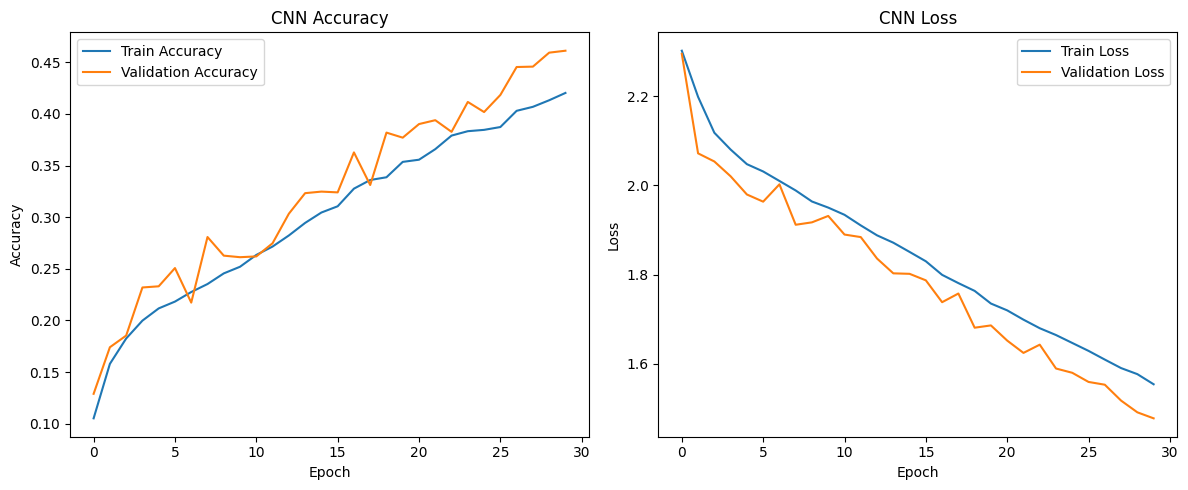

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()

Visualized the training and validation accuracy and loss across epochs to examine the CNN's learning behavior during training.

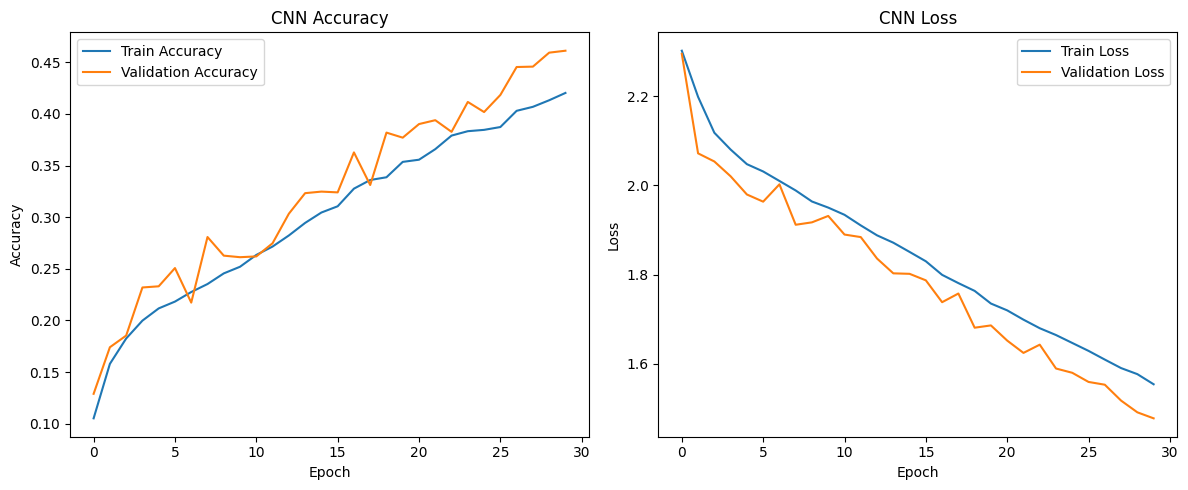

CNN training curves saved.
/content/drive/MyDrive/Galaxy10_CNN/cnn_training_curves.png


In [ ]:
cnn_curve_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_training_curves.png"

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.tight_layout()
plt.savefig(cnn_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN training curves saved.")
print(cnn_curve_path)

Generated the same training and validation curves and saved the resulting figure as a high-resolution PNG file.

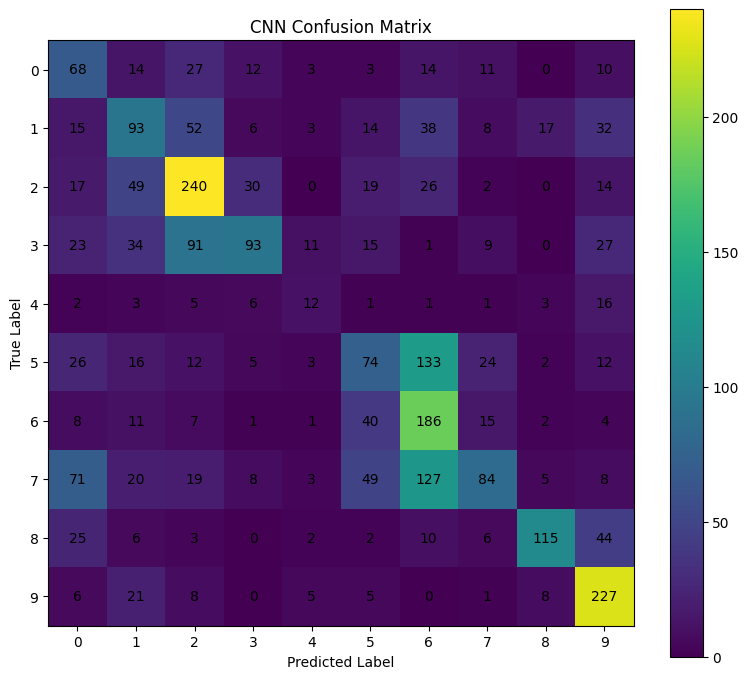

In [ ]:
plt.figure(figsize=(8, 7))

plt.imshow(cm_cnn, interpolation="nearest")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_cnn[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

Displayed the CNN confusion matrix as a graphical matrix and added the numerical prediction counts to each cell for easier interpretation.

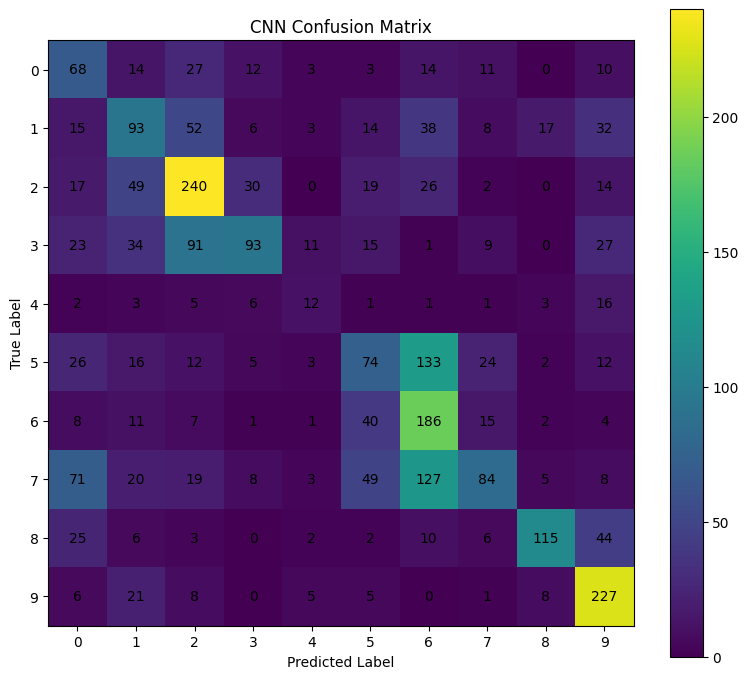

CNN confusion matrix saved.
/content/drive/MyDrive/Galaxy10_CNN/cnn_confusion_matrix.png


In [ ]:
cnn_cm_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_confusion_matrix.png"

plt.figure(figsize=(8, 7))

plt.imshow(cm_cnn, interpolation="nearest")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_cnn[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.savefig(cnn_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("CNN confusion matrix saved.")
print(cnn_cm_path)

Generated the CNN confusion matrix visualization again and saved it as a high-resolution image for inclusion in the project results.

The CNN successfully identifies some distinctive galaxy categories, especially Classes 2 and 9, but shows considerable overlap between visually similar morphological classes. The strong concentration of predictions around Classes 2 and 6 indicates difficulty in separating several related galaxy morphologies.

In [ ]:
import pandas as pd

comparison = {
    "Model": ["CNN", "ViT"],
    "Parameters": [422602, 545546],
    "Best Validation Accuracy": [0.4613, 0.6459],
    "Test Accuracy": [0.4480, 0.6268],
    "Macro F1": [0.4222, 0.5964],
    "Weighted F1": [0.4349, 0.6233]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df.to_string(index=False))

Model  Parameters  Best Validation Accuracy  Test Accuracy  Macro F1  Weighted F1
  CNN      422602                    0.4613         0.4480    0.4222       0.4349
  ViT      545546                    0.6459         0.6268    0.5964       0.6233


Created a comparison table containing the number of parameters, best validation accuracy, test accuracy, macro F1, and weighted F1 for both the CNN and Vision Transformer models.

In [ ]:
cnn_values = comparison_df.iloc[0]
vit_values = comparison_df.iloc[1]

print("ViT - CNN differences:")
print(f"Best Validation Accuracy: {(vit_values['Best Validation Accuracy'] - cnn_values['Best Validation Accuracy']) * 100:.2f} percentage points")
print(f"Test Accuracy: {(vit_values['Test Accuracy'] - cnn_values['Test Accuracy']) * 100:.2f} percentage points")
print(f"Macro F1: {(vit_values['Macro F1'] - cnn_values['Macro F1']) * 100:.2f} percentage points")
print(f"Weighted F1: {(vit_values['Weighted F1'] - cnn_values['Weighted F1']) * 100:.2f} percentage points")
print(f"Additional Parameters: {vit_values['Parameters'] - cnn_values['Parameters']:,}")

ViT - CNN differences:
Best Validation Accuracy: 18.46 percentage points
Test Accuracy: 17.88 percentage points
Macro F1: 17.42 percentage points
Weighted F1: 18.84 percentage points
Additional Parameters: 122,944


Calculated the differences between the Vision Transformer and CNN in validation accuracy, test accuracy, macro F1, weighted F1, and parameter count.

In [ ]:
comparison_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.csv"

comparison_df = comparison_df.iloc[:, :6]  # remove the incorrect NaN column

comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved:")
print(comparison_path)

Comparison saved:
/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.csv


Saved the CNN-vs-ViT comparison table as a CSV file for further analysis and reporting.

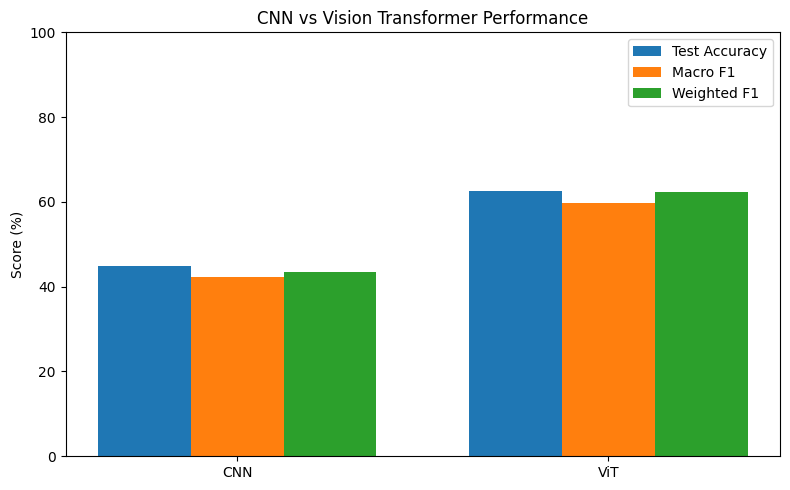

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["CNN", "ViT"]
test_accuracy = [44.80, 62.68]
macro_f1 = [42.22, 59.64]
weighted_f1 = [43.49, 62.33]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, test_accuracy, width, label="Test Accuracy")
plt.bar(x, macro_f1, width, label="Macro F1")
plt.bar(x + width, weighted_f1, width, label="Weighted F1")

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.title("CNN vs Vision Transformer Performance")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
comparison_fig_path = "/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.png"

plt.savefig(comparison_fig_path, dpi=300, bbox_inches="tight")

print("Comparison figure saved:")
print(comparison_fig_path)

Comparison figure saved:
/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.png


<Figure size 640x480 with 0 Axes>

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Galaxy10_CNN_vs_ViT"
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project folder ready:")
print(PROJECT_DIR)

Project folder ready:
/content/drive/MyDrive/Galaxy10_CNN_vs_ViT


Created a dedicated Google Drive folder for collecting the final outputs from the CNN and Vision Transformer experiments.

In [ ]:
import shutil
import os

files_to_copy = [
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_results.txt",
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_evaluation.txt",
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_training_curves.png",
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_confusion_matrix.png",
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.csv",
    "/content/drive/MyDrive/Galaxy10_CNN/cnn_vs_vit_comparison.png",
    "/content/drive/MyDrive/Galaxy10_ViT/vit_results.txt",
]

for file_path in files_to_copy:
    if os.path.exists(file_path):
        shutil.copy2(file_path, PROJECT_DIR)
        print("Copied:", os.path.basename(file_path))
    else:
        print("NOT FOUND:", file_path)

print("\nProject results collected.")

Copied: cnn_results.txt
Copied: cnn_evaluation.txt
Copied: cnn_training_curves.png
Copied: cnn_confusion_matrix.png
Copied: cnn_vs_vit_comparison.csv
Copied: cnn_vs_vit_comparison.png
Copied: vit_results.txt

Project results collected.


Copied the important CNN and Vision Transformer result files including performance summaries, evaluation results, training curves, confusion matrices, and comparison files into the final project folder.

In [ ]:
VIT_DIR = "/content/drive/MyDrive/Galaxy10_ViT"

print("Files in Galaxy10_ViT:")
for name in sorted(os.listdir(VIT_DIR)):
    print("-", name)

Files in Galaxy10_ViT:
- best_vit.weights.h5
- checkpoint_test.keras
- class_weights.npy
- project_info.txt
- test_indices.npy
- train_indices.npy
- val_indices.npy
- vit_results.txt


Displayed the files available in the Vision Transformer results directory to verify that the expected model and result files were present.

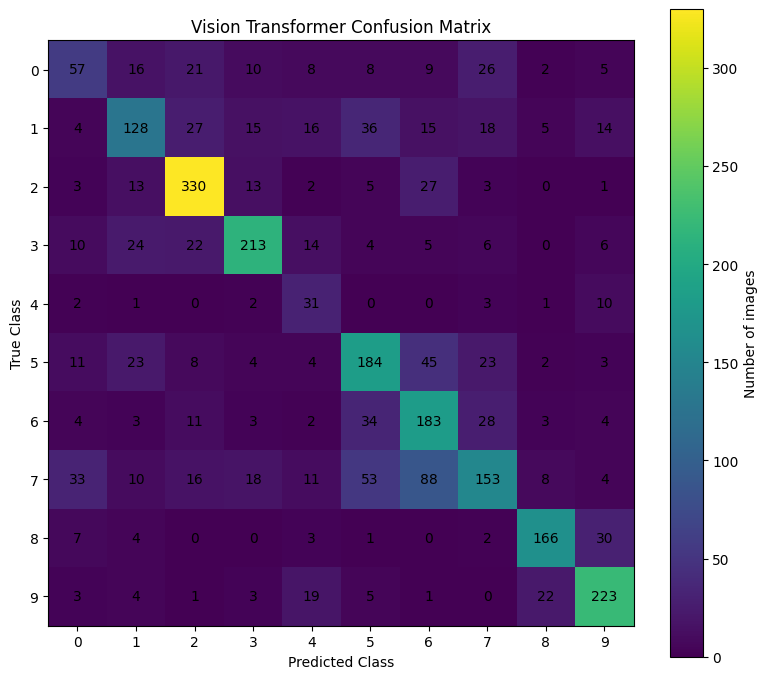

ViT confusion matrix overwritten correctly.
/content/drive/MyDrive/Galaxy10_CNN_vs_ViT/vit_confusion_matrix.png


In [ ]:
plt.figure(figsize=(8, 7))
plt.imshow(vit_cm)

plt.colorbar(label="Number of images")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Vision Transformer Confusion Matrix")

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, vit_cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.savefig(vit_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("ViT confusion matrix overwritten correctly.")
print(vit_cm_path)

The Vision Transformer demonstrates stronger class separation, with substantially higher diagonal values across most categories and reduced confusion between visually similar galaxy classes. Although Classes 5, 6, and 7 remain challenging, the ViT provides a more balanced classification pattern than the CNN.